# AS7341 CSV Calibration Workflow

This notebook reads the labeled calibration CSV generated by the Uno Q data-gather app, validates the `color_name, channel1..channel10` schema, normalizes the AS7341 vectors, and recomputes the class centroids used by the embedded classifier.

The canonical class order is kept identical to the sorter classifier: `orange`, `purple`, `blue`, `green`, `yellow`, `pink`, `red`.
This notebook intentionally keeps a simple local duplicate of the production analysis algorithm so it remains usable offline. When the calibration logic changes in the Uno Q Python app, the same change must be mirrored here and the outputs must be compared on the same CSV.

In [ ]:
import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

sns.set_theme(style="whitegrid", context="talk")

DATA_PATH = Path.cwd() / "color_sensor_samples.csv"
FEATURE_NAMES = [f"channel{index}" for index in range(1, 11)]
CLASS_ORDER = ["orange", "purple", "blue", "green", "yellow", "pink", "red"]
CLASS_COLOR_MAP = {
    "orange": "#ff8c00",
    "purple": "#7b2cbf",
    "blue": "#1f77b4",
    "green": "#2ca02c",
    "yellow": "#ffe600",
    "pink": "#e75480",
    "red": "#ff0000",
}
UNKNOWN_DISTANCE_PERCENTILE = 95
EXPECTED_HEADER = ["color_name", *FEATURE_NAMES]
HEADER_DOC_AUTHOR = "David Goletta"
HEADER_DOC_DATE = "2026-06-18"


def load_labeled_samples(path: Path) -> tuple[np.ndarray, np.ndarray]:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing calibration CSV at {path}. Capture samples first."
        )

    labels: list[str] = []
    rows: list[list[float]] = []

    with path.open(newline="", encoding="utf-8") as csv_file:
        reader = csv.DictReader(csv_file)
        if reader.fieldnames != EXPECTED_HEADER:
            raise ValueError(
                f"Unexpected CSV header {reader.fieldnames!r}. Expected {EXPECTED_HEADER!r}."
            )

        for row in reader:
            color_name = row["color_name"].strip().lower()
            if color_name not in CLASS_ORDER:
                raise ValueError(f"Unsupported color label {color_name!r} in {path}.")

            sample = [float(row[feature_name]) for feature_name in FEATURE_NAMES]
            labels.append(color_name)
            rows.append(sample)

    if not rows:
        raise ValueError("The calibration CSV is empty.")

    X_values = np.asarray(rows, dtype=float)
    y_labels = np.asarray(labels, dtype=object)

    if X_values.ndim != 2:
        raise ValueError(f"Expected a 2D feature matrix, got shape {X_values.shape}.")
    if X_values.shape[1] != 10:
        raise ValueError(f"Expected 10 features, got {X_values.shape[1]}.")

    missing_classes = [label for label in CLASS_ORDER if label not in set(y_labels.tolist())]
    if missing_classes:
        raise ValueError(
            "Missing labeled classes in the CSV: " + ", ".join(missing_classes)
        )

    return X_values, y_labels


def format_float(value: float) -> str:
    return f"{value:.8f}f"


def compute_outer_confidence_radii(centroids: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    centroid_distances = np.linalg.norm(
        centroids[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2
    )
    np.fill_diagonal(centroid_distances, np.inf)

    nearest_centroid_distances = centroid_distances.min(axis=1)
    outer_confidence_radii = nearest_centroid_distances / 2.0
    return outer_confidence_radii, nearest_centroid_distances


def build_cpp_code(
    centroids: np.ndarray,
    inner_confidence_radius: float,
    outer_confidence_radii: np.ndarray,
) -> str:
    centroid_rows = [
        "    {" + ", ".join(format_float(value) for value in row) + "}"
        for row in centroids
    ]
    outer_radius_values = ", ".join(
        format_float(value) for value in outer_confidence_radii
    )

    lines: list[str] = [
        "#pragma once",
        "",
        "#include <stddef.h>",
        "",
        "namespace BallClassifier {",
        "",
        "/**",
        " * @brief Number of input features consumed by the color classifier.",
        f" * @author {HEADER_DOC_AUTHOR}",
        f" * @date {HEADER_DOC_DATE}",
        " */",
        f"constexpr size_t kFeatureCount = {len(FEATURE_NAMES)};",
        "",
        "/**",
        " * @brief Number of known classes handled by the color classifier.",
        f" * @author {HEADER_DOC_AUTHOR}",
        f" * @date {HEADER_DOC_DATE}",
        " */",
        f"constexpr size_t kClassCount = {len(CLASS_ORDER)};",
        "",
        "/**",
        " * @brief Canonical class labels aligned with the trained centroid table.",
        f" * @author {HEADER_DOC_AUTHOR}",
        f" * @date {HEADER_DOC_DATE}",
        " */",
        "constexpr const char* kClassNames[kClassCount] = {",
    ]
    for label in CLASS_ORDER:
        lines.append(f'    "{label}",')
    lines.append("};")
    lines.append("")
    lines.extend(
        [
            "/**",
            " * @brief Trained normalized centroids for the supported ball colors.",
            f" * @author {HEADER_DOC_AUTHOR}",
            f" * @date {HEADER_DOC_DATE}",
            " *",
            " * Rows follow `kClassNames` and columns follow the 10-feature AS7341 layout.",
            " */",
            "constexpr float kClassCentroids[kClassCount][kFeatureCount] = {",
        ]
    )
    for index, row in enumerate(centroid_rows):
        suffix = "," if index < len(centroid_rows) - 1 else ""
        lines.append(f"{row}{suffix}")
    lines.append("};")
    lines.append("")
    lines.extend(
        [
            "/**",
            " * @brief Global inner radius that maps to 100% confidence.",
            f" * @author {HEADER_DOC_AUTHOR}",
            f" * @date {HEADER_DOC_DATE}",
            " */",
            f"constexpr float kInnerConfidenceRadius = {inner_confidence_radius:.8f}f;",
            "",
            "/**",
            " * @brief Class-specific outer radii where confidence falls to 0%.",
            f" * @author {HEADER_DOC_AUTHOR}",
            f" * @date {HEADER_DOC_DATE}",
            " *",
            " * Each entry shares the index of the corresponding `kClassNames` centroid.",
            " */",
            "constexpr float kOuterConfidenceRadii[kClassCount] = "
            + "{" + outer_radius_values + "};",
            "",
            "}  // namespace BallClassifier",
        ]
    )
    return "\n".join(lines) + "\n"

In [6]:
X, labels = load_labeled_samples(DATA_PATH)
X_norm = normalize(X, norm="l2")
class_to_id = {label: index for index, label in enumerate(CLASS_ORDER)}
class_ids = np.array([class_to_id[label] for label in labels])
class_sizes = {label: int(np.sum(labels == label)) for label in CLASS_ORDER}
centroids = np.vstack([X_norm[labels == label].mean(axis=0) for label in CLASS_ORDER])
assigned_distances = np.linalg.norm(X_norm - centroids[class_ids], axis=1)
inner_confidence_radius = float(np.percentile(assigned_distances, UNKNOWN_DISTANCE_PERCENTILE))
outer_confidence_radii, nearest_centroid_distances = compute_outer_confidence_radii(centroids)

if len(np.unique(class_ids)) > 1 and len(X_norm) > len(CLASS_ORDER):
    silhouette = float(silhouette_score(X_norm, class_ids))
else:
    silhouette = float("nan")

print(f"Loaded {len(X)} labeled samples from {DATA_PATH}.")
print(f"Feature count: {X.shape[1]}")
print("Class sizes:")
for label in CLASS_ORDER:
    print(f"  {label:>6}: {class_sizes[label]}")

if np.isnan(silhouette):
    print("Silhouette score: not enough samples per class yet.")
else:
    print(f"Silhouette score: {silhouette:.3f}")

print(
    f"Inner confidence radius ({UNKNOWN_DISTANCE_PERCENTILE}th percentile): "
    f"{inner_confidence_radius:.8f}"
)
print("Outer confidence radii (half of nearest centroid distance):")
for index, label in enumerate(CLASS_ORDER):
    print(
        f"  {label:>6}: {outer_confidence_radii[index]:.8f} "
        f"(nearest centroid distance: {nearest_centroid_distances[index]:.8f})"
    )

Loaded 700 labeled samples from c:\Users\david\OneDrive - Education Vaud\M2614 La face cachée de la lune\10_Informatique\Code\ball-analyzer\color_sensor_samples.csv.
Feature count: 10
Class sizes:
  orange: 100
  purple: 100
    blue: 100
   green: 100
  yellow: 100
    pink: 100
     red: 100
Silhouette score: 0.993
Inner confidence radius (95th percentile): 0.00202114
Outer confidence radii (half of nearest centroid distance):
  orange: 0.05600741 (nearest centroid distance: 0.11201482)
  purple: 0.09871508 (nearest centroid distance: 0.19743015)
    blue: 0.09871508 (nearest centroid distance: 0.19743015)
   green: 0.08474379 (nearest centroid distance: 0.16948759)
  yellow: 0.05600741 (nearest centroid distance: 0.11201482)
    pink: 0.06471307 (nearest centroid distance: 0.12942615)
     red: 0.06471307 (nearest centroid distance: 0.12942615)


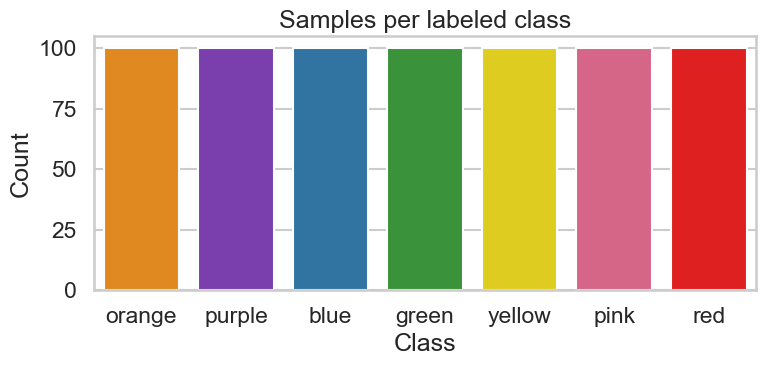

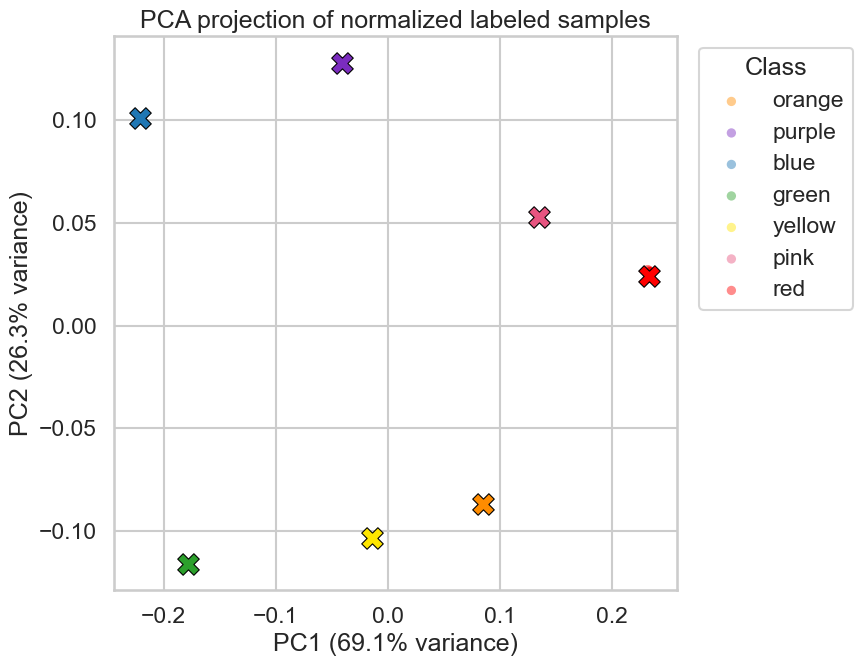

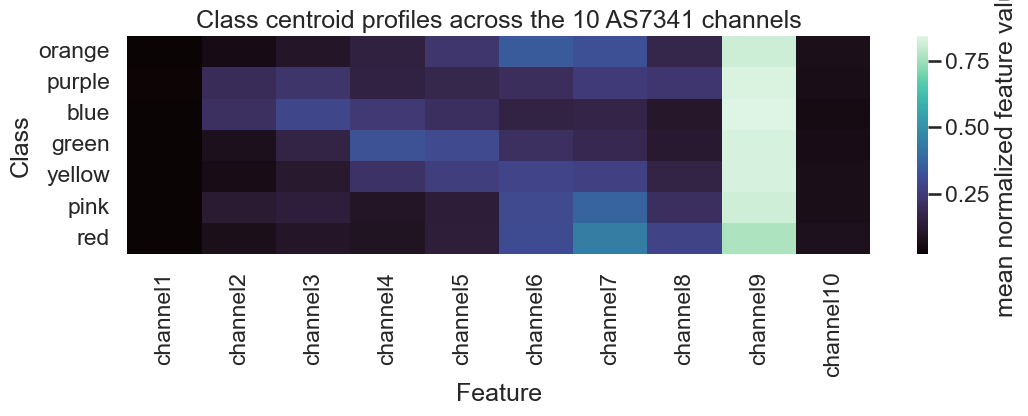

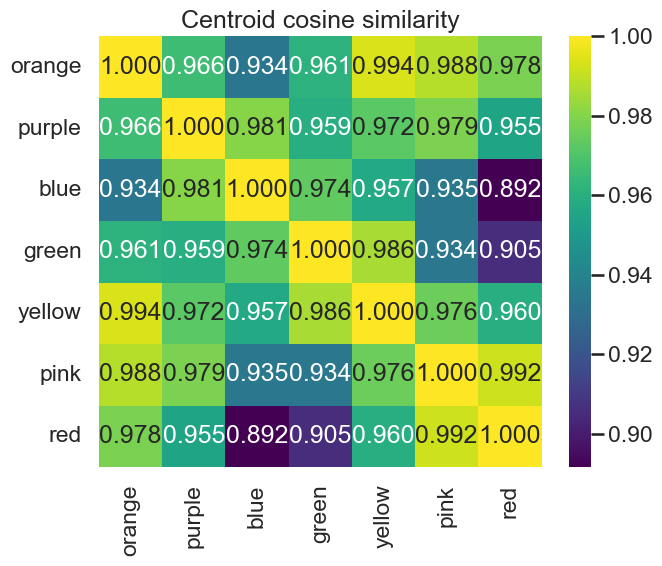

In [7]:
plt.figure(figsize=(8, 4))
sns.countplot(x=labels, hue=labels, order=CLASS_ORDER, palette=CLASS_COLOR_MAP, legend=False)
plt.title("Samples per labeled class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_norm)
centroids_pca = pca.transform(centroids)

plt.figure(figsize=(9, 7))
for class_index, label in enumerate(CLASS_ORDER):
    members = labels == label
    plt.scatter(
        X_pca[members, 0],
        X_pca[members, 1],
        s=45,
        alpha=0.45,
        color=CLASS_COLOR_MAP[label],
        edgecolor="none",
        label=label,
    )
    plt.scatter(
        centroids_pca[class_index, 0],
        centroids_pca[class_index, 1],
        s=240,
        marker="X",
        color=CLASS_COLOR_MAP[label],
        edgecolor="black",
        linewidth=0.8,
    )

plt.title("PCA projection of normalized labeled samples")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.legend(title="Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4.5))
sns.heatmap(
    centroids,
    cmap="mako",
    xticklabels=FEATURE_NAMES,
    yticklabels=CLASS_ORDER,
    cbar_kws={"label": "mean normalized feature value"},
)
plt.title("Class centroid profiles across the 10 AS7341 channels")
plt.xlabel("Feature")
plt.ylabel("Class")
plt.tight_layout()
plt.show()

similarity_matrix = cosine_similarity(centroids)
plt.figure(figsize=(7, 6))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
)
plt.title("Centroid cosine similarity")
plt.tight_layout()
plt.show()
            

In [8]:
cpp_code = build_cpp_code(
    centroids,
    inner_confidence_radius,
    outer_confidence_radii,
    )

print(cpp_code)

/**
 * @brief Canonical class labels aligned with the trained centroid table.
 * @author David Goletta
 * @date 2026-06-18
 */
constexpr const char* kClassNames[kClassCount] = {
    "orange",
    "purple",
    "blue",
    "green",
    "yellow",
    "pink",
    "red",
};

/**
 * @brief Trained normalized centroids for the supported ball colors.
 * @author David Goletta
 * @date 2026-06-18
 *
 * Rows follow `kClassNames` and columns follow the 10-feature AS7341 layout.
 */
constexpr float kClassCentroids[kClassCount][kFeatureCount] = {
    {0.02176572f, 0.05861964f, 0.10047679f, 0.14750951f, 0.23121250f, 0.34431710f, 0.31493234f, 0.17167382f, 0.81148065f, 0.07118026f},
    {0.02719150f, 0.19254453f, 0.22986130f, 0.15292251f, 0.17360606f, 0.20127188f, 0.24925770f, 0.23367468f, 0.83320580f, 0.06595952f},
    {0.02427890f, 0.20775988f, 0.28599793f, 0.24360660f, 0.20450618f, 0.15539665f, 0.16185104f, 0.10542755f, 0.84196078f, 0.05410646f},
    {0.02226513f, 0.07439216f, 0.15796030f, 0.319296